# COUGHVID Analysis
A repo to analyze the COUGHVID dataset.

### Data source
Raw data: https://zenodo.org/records/7024894
Article: https://www.nature.com/articles/s41597-021-00937-4

## Technical Requirements:
FFmpeg to decode audio files 
```
brew install ffmpeg
```

### Research Questions (decide for one)
#### RQ1
Can acoustic features extracted from cough recordings reliably distinguish COVID-19 positive individuals from healthy and symptomatic individuals?

#### RQ2
Do cough recordings from individuals with pre-existing respiratory conditions (e.g., asthma, COPD) exhibit distinct acoustic feature distributions compared to those without such conditions?

### 0 - Setup and Imports

In [112]:
# Step 0 - Setup and Imports
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

import librosa
import av
import os
import soundfile as sf

# warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")

# Define paths and constants
DATA_ROOT = Path("COUGHVIDdataset")
METADATA_PATH = DATA_ROOT / "metadata_compiled.csv"
AUDIO_EXTS = {".wav", ".ogg", ".webm"}

IS_DEV = False  # Set to False for full run

print(f"Metadata file exists: {METADATA_PATH.exists()}")
print(f"Data root: {DATA_ROOT.resolve()}")

Metadata file exists: True
Data root: /Users/georg/Developer/uni/coughvid_analysis/COUGHVIDdataset


### 1 - Data Loading
Data Loading and filtering out a subset for faster development

In [87]:
# Step 1 - Load metadata and perform early prepocessing:
# - Set UUID as index
# - Parse datetime
# - Normalize numeric columns (coerce errors to NaN)
# - Normalize selected categorical-like columns (strip, lowercase)
# - Count audio files and keep only rows with an existing audio recording

df = pd.read_csv(METADATA_PATH)
df = df.set_index("uuid")

# Parse datetime
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# normalize numeric columns. Coerce errors to NaN
for col in ["cough_detected", "age", "latitude", "longitude"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Normalize selected categorical-like columns
for col in ["gender", "status", "status_SSL", "respiratory_condition", "fever_muscle_pain"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip().str.lower()

# Count audio files and keep only rows with an existing audio recording
audio_paths = [p for p in DATA_ROOT.glob("*") if p.suffix.lower() in AUDIO_EXTS]
audio_by_uuid = {p.stem: p for p in audio_paths}

# Add audio path to dataframe
df["audio_path"] = df.index.map(lambda u: str(audio_by_uuid.get(str(u), "")))
df["has_audio"] = df["audio_path"].str.len() > 0

# filter to rows with audio for further analysis
df_audio = df[df["has_audio"]].copy()
display(df_audio.index)
display(df_audio.head())

if IS_DEV:
    df_audio = df_audio.sample(2000, random_state=42)

print(f"All metadata rows: {len(df):,}")
print(f"Rows with matched audio: {len(df_audio):,}")
print("Audio extension counts:")
print(pd.Series([Path(p).suffix.lower() for p in df_audio["audio_path"]]).value_counts(dropna=False).to_string())

Index(['00014dcc-0f06-4c27-8c7b-737b18a2cf4c', '00039425-7f3a-42aa-ac13-834aaa2b6b92', '0007c6f1-5441-40e6-9aaf-a761d8f2da3b',
       '00098cdb-4da1-4aa7-825a-4f1b9abc214b', '0009eb28-d8be-4dc1-92bb-907e53bc5c7a', '0012c608-33d0-4ef7-bde3-75a0b1a0024e',
       '001328dc-ea5d-4847-9ccf-c5aa2a3f2d0f', '00196ba6-0087-484b-a104-3e8884599596', '001c85a8-cc4d-4921-9297-848be52d4715',
       '001d8e33-a4af-4edb-98ba-b03f891d9a6c',
       ...
       'ffe8b243-9c7b-49f1-8d7d-a953f736ea4b', 'ffedc843-bfc2-4ad6-a749-2bc86bdac84a', 'ffeea120-92a4-40f9-b692-c3865c7a983f',
       'fff13fa2-a725-49ef-812a-39c6cedda33d', 'fff30afc-db62-4408-a585-07ca9a254fcc', 'fff3ff61-2387-4139-938b-539db01e6be5',
       'fff474bf-39a4-4a61-8348-6b992fb5e439', 'fffaa9f8-4db0-46c5-90fb-93b7b014b55d', 'fffce9f0-a5e8-4bee-b13b-c671aac4a61c',
       'fffd1834-6cf2-4782-bb30-04c31b46a1fe'],
      dtype='str', name='uuid', length=34434)

,Unnamed: 0,datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,status_SSL,quality_1,cough_type_1,dyspnea_1,wheezing_1,stridor_1,choking_1,congestion_1,nothing_1,diagnosis_1,severity_1,quality_2,cough_type_2,dyspnea_2,wheezing_2,stridor_2,choking_2,congestion_2,nothing_2,diagnosis_2,severity_2,quality_3,cough_type_3,dyspnea_3,wheezing_3,stridor_3,choking_3,congestion_3,nothing_3,diagnosis_3,severity_3,quality_4,cough_type_4,dyspnea_4,wheezing_4,stridor_4,choking_4,congestion_4,nothing_4,diagnosis_4,severity_4,audio_path,has_audio
uuid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00014dcc-0f06-4c27-8c7b-737b18a2cf4c,0,2020-11-25 18:58:50.488301+00:00,0.0155,48.9,2.4,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COUGHVIDdataset/00014dcc-0f06-4c27-8c7b-737b18...,True
00039425-7f3a-42aa-ac13-834aaa2b6b92,1,2020-04-13 21:30:59.801831+00:00,0.9609,31.3,34.8,15.0,male,false,false,healthy,healthy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COUGHVIDdataset/00039425-7f3a-42aa-ac13-834aaa...,True
0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2,2020-10-18 15:38:38.205870+00:00,0.1643,NaN,NaN,46.0,female,false,false,healthy,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COUGHVIDdataset/0007c6f1-5441-40e6-9aaf-a761d8...,True
00098cdb-4da1-4aa7-825a-4f1b9abc214b,3,2021-01-22 22:08:06.742577+00:00,0.1133,47.4,9.4,66.0,female,false,false,healthy,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COUGHVIDdataset/00098cdb-4da1-4aa7-825a-4f1b9a...,True
0009eb28-d8be-4dc1-92bb-907e53bc5c7a,4,2020-04-12 04:02:18.159383+00:00,0.9301,40.0,-75.1,34.0,male,true,false,healthy,healthy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COUGHVIDdataset/0009eb28-d8be-4dc1-92bb-907e53...,True


All metadata rows: 34,434
Rows with matched audio: 34,434
Audio extension counts:
.webm    29348
.wav      3309
.ogg      1777


### 2 - Exploratory Data Analysis

In [88]:
# Step 2 - Exploratory Data Analysis (EDA)
eda_df = df_audio.copy()

#### 2.1 Metadata Exploration
1. Numerical features: Summary statistics
2. Categorical variables: Frequency tables and class distributions
3. Missing data / Outliers detection

In [89]:
# 2.1.1 Numerical features: summary statistics
num_df = eda_df.select_dtypes(include=[np.number]).copy()

# If no numerical columns are found, skip this part

# Summary statistics using describe
desc = num_df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

print(f"Numerical columns: {num_df.shape[1]}")
display(desc)

Numerical columns: 5


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Unnamed: 0,34434.0,17216.500000,9940.383921,0.0,344.330000,1721.6500,8608.25000,17216.50000,25824.7500,32711.3500,34088.6700,34433.0000
cough_detected,34434.0,0.641199,0.383535,0.0,0.005833,0.0159,0.20515,0.85045,0.9773,0.9955,0.9978,0.9994
latitude,19431.0,33.301750,21.517910,-54.8,-34.800000,-22.9000,33.70000,41.00000,46.3000,50.1000,55.8000,65.1000
longitude,19431.0,7.632628,53.968134,-158.1,-116.900000,-83.2000,-3.80000,6.60000,32.5000,106.4000,139.8000,175.7000
age,19396.0,36.758749,14.833325,1.0,10.000000,16.0000,25.00000,35.00000,46.0000,64.0000,76.0000,102.0000


In [90]:
# Step 2.1.2 Categorical features: frequency tables and class distributions
# For each column show:
# - Number of non-null values
# - Percentage of non-null values
# - Number of unique values
# - Top class and its count and percentage
# Furthermore show frequency tables for each categorical column

cat_df = eda_df.select_dtypes(include=["object", "string", "category", "bool"]).copy()
print(f"Categorical columns: {cat_df.shape[1]}")

# Number of non-null values, unique values
class_overview = pd.DataFrame({
    "n_non_null": cat_df.notna().sum(),
    "n_unique": cat_df.nunique(dropna=True)
})

# Percentage of non-null values
class_overview["pct_non_null"] = (
    class_overview["n_non_null"] / len(cat_df) * 100
).round(2)

# Top class, its count and percentage
class_overview["top_class"] = cat_df.apply(
    lambda s: s.dropna().value_counts().index[0] if s.dropna().shape[0] else pd.NA
)
class_overview["top_class_n"] = cat_df.apply(
    lambda s: int(s.dropna().value_counts().iloc[0]) if s.dropna().shape[0] else 0
)
class_overview["top_class_pct"] = cat_df.apply(
    lambda s: round(
        s.dropna().value_counts(normalize=True).iloc[0] * 100, 2
    ) if s.dropna().shape[0] else np.nan
)

display(class_overview)

# Per-column frequency tables (class distributions).
for col in cat_df.columns:
    # Exclude audio_path, has_audio from this detailed frequency analysis
    if col in ["audio_path", "has_audio"]:
        continue
    print(f"\n=== {col} ===")
    freq = cat_df[col].dropna().value_counts().rename("count").to_frame()
    freq["pct"] = (freq["count"] / freq["count"].sum() * 100).round(2)
    display(freq)

Categorical columns: 47


,n_non_null,n_unique,pct_non_null,top_class,top_class_n,top_class_pct
gender,20664,3,60.01,male,12850,62.19
respiratory_condition,20664,2,60.01,false,17107,82.79
fever_muscle_pain,20664,2,60.01,false,18179,87.97
status,20664,3,60.01,healthy,15476,74.89
status_SSL,8331,2,24.19,healthy,8046,96.58
quality_1,820,4,2.38,ok,614,74.88
cough_type_1,820,3,2.38,dry,425,51.83
dyspnea_1,820,2,2.38,False,815,99.39
wheezing_1,820,2,2.38,False,765,93.29
stridor_1,820,1,2.38,False,820,100.00



=== gender ===


,count,pct
gender,,
male,12850,62.19
female,7682,37.18
other,132,0.64



=== respiratory_condition ===


...

,count,pct
nothing_4,,
True,684,83.41
False,136,16.59



=== diagnosis_4 ===


,count,pct
diagnosis_4,,
upper_infection,313,39.57
healthy_cough,221,27.94
lower_infection,121,15.30
COVID-19,84,10.62
obstructive_disease,52,6.57



=== severity_4 ===


,count,pct
severity_4,,
mild,472,58.85
pseudocough,221,27.56
severe,69,8.60
unknown,40,4.99


In [91]:
# ------------------------
# Missing data analysis
# ------------------------

# Missing percentage per column, sorted from lowest to highest missingness.
missing_rate = (eda_df.isna().mean() * 100).sort_values(ascending=True)
missing_ct = eda_df.isna().sum().loc[missing_rate.index]

# Consolidated missingness table with count, percent, and dtype.
ct = pd.DataFrame({
    "missing_count": missing_ct,
    "missing_pct": missing_rate.round(2),
    "dtype": eda_df[missing_rate.index].dtypes.astype(str).values,
})

print("Columns with most data present (top 20):")
display(ct.head(20))

# Flag columns that are almost entirely missing.
high_missing = ct[ct["missing_pct"] > 90]
if high_missing.empty:
    print("No columns exceed 90% missingness.")
else:
    print("Columns with >90% missingness (consider dropping or special handling):")
    display(high_missing)

# Optional check: compare missingness across status groups to detect bias.
# if "status" in eda_df.columns:
#     group_n = min(10, len(ct))
#     top_k = ct.head(group_n).index.tolist()
#     miss_by_status = (
#         eda_df.groupby("status", dropna=False)[top_k]
#         .apply(lambda x: x.isna().mean() * 100)
#         .round(2)
#     )
#     print(f"Missingness by status for top {group_n} most-missing columns (%):")
#     display(miss_by_status)





Columns with most data present (top 20):


,missing_count,missing_pct,dtype
Unnamed: 0,0,0.00,int64
audio_path,0,0.00,str
has_audio,0,0.00,bool
datetime,0,0.00,"datetime64[us, UTC]"
cough_detected,0,0.00,float64
gender,13770,39.99,string
respiratory_condition,13770,39.99,string
fever_muscle_pain,13770,39.99,string
status,13770,39.99,string
latitude,15003,43.57,float64


Columns with >90% missingness (consider dropping or special handling):


,missing_count,missing_pct,dtype
severity_2,33614,97.62,str
quality_3,33614,97.62,str
dyspnea_3,33614,97.62,object
wheezing_3,33614,97.62,object
stridor_3,33614,97.62,object
choking_3,33614,97.62,object
wheezing_4,33614,97.62,object
nothing_3,33614,97.62,object
quality_4,33614,97.62,str
dyspnea_4,33614,97.62,object


IQR-based outlier summary:


,column,n,q1,q3,iqr,lower_bound,upper_bound,outlier_n,outlier_pct
3,longitude,19431,-3.80000,32.5000,36.30000,-58.250000,86.950000,4516,23.24
2,latitude,19431,33.70000,46.3000,12.60000,14.800000,65.200000,2899,14.92
4,age,19396,25.00000,46.0000,21.00000,-6.500000,77.500000,151,0.78
0,Unnamed: 0,34434,8608.25000,25824.7500,17216.50000,-17216.500000,51649.500000,0,0.00
1,cough_detected,34434,0.20515,0.9773,0.77215,-0.953075,2.135525,0,0.00


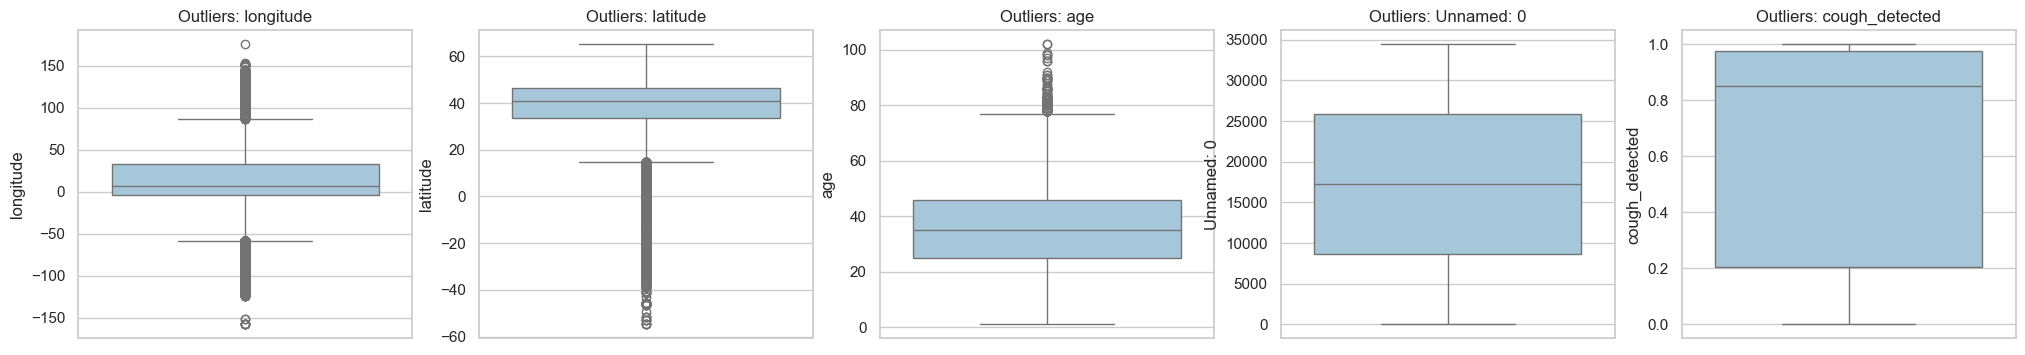

In [92]:
# -----------------------------------
# Numeric outlier diagnostics (IQR)
# -----------------------------------
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()

# Optional exclusion for helper columns not meaningful for outlier detection.
# numeric_cols = [c for c in numeric_cols if c not in ["has_audio"]]

outlier_rows = []
for i, col in enumerate(numeric_cols):
    # Non-missing values for the current numeric column.
    values = eda_df[col].dropna()
    target_n = int(values.shape[0])

    # Minimum sample-size guard (disabled for now).
    # if target_n < 10:
    #     continue

    # IQR rule: values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are outliers.
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    # Constant columns (IQR == 0) do not have IQR-defined outliers.
    if iqr == 0:
        continue

    # Compute bounds and outlier counts.
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    is_outlier = (values < lower) | (values > upper)
    out_n = int(is_outlier.sum())
    out_pct = round(out_n / target_n * 100, 2)

    outlier_rows.append({
        "column": col,
        "n": target_n,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_n": out_n,
        "outlier_pct": out_pct,
    })

if len(outlier_rows) == 0:
    print("No numeric columns with enough variability for IQR outlier detection.")
else:
    # Rank columns by outlier prevalence.
    outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
    print("IQR-based outlier summary:")
    display(outlier_df)

    # Visualize columns ordered by highest outlier percentage.
    n_outlier_cols = outlier_df.shape[0]
    ordered_cols = outlier_df.head(n_outlier_cols)["column"].tolist()
    fig, axes = plt.subplots(1, n_outlier_cols, figsize=(5 * n_outlier_cols, 4))

    # Keep axes iterable even when there is only one subplot.
    if n_outlier_cols == 1:
        axes = np.array([axes])

    # Draw one boxplot per selected column.
    for ax, col in zip(axes, ordered_cols):
        sns.boxplot(y=eda_df[col], ax=ax, color="#9ecae1")
        ax.set_title(f"Outliers: {col}")
        ax.set_ylabel(col)

    plt.show()

#### 2.2 Audio Signal Exploration
- Waveform characteristics (duration, amplitude range, sampling rate)
- Visualize representative examples
- Identify potential inconsistencies

In [93]:
# ------------------------------
# Helper function to load audio
# ------------------------------

def load_audio(audio_path, sampling_rate=None, mono=False) -> tuple[np.ndarray, int]:
    """Load audio using librosa
    params:
    - audio_path: path to the audio file (str or Path)
    - sampling_rate: target sampling rate (int, optional). If None, uses original.
    - mono: whether to convert to mono (bool, default False)
    returns:
    - Tuple of (audio_data as np.ndarray, sample_rate as int)
    """
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            category=UserWarning,
            message=r"PySoundFile failed\. Trying audioread instead\.",
        )
        warnings.filterwarnings(
            "ignore",
            category=FutureWarning,
            message=r"librosa\.core\.audio\.__audioread_load.*",
        )
        data, sample_rate = librosa.load(audio_path, sr=sampling_rate, mono=mono)
    return data.astype(np.float32), int(sample_rate)

# ----------------------------------------------
# Helper function to extract audio features
# ----------------------------------------------
def extract_audio_features(audio_path):
    """
    Load an audio file and extract key characteristics.

    Parameters:
    - audio_path: path to the audio file (str)

    Returns:
    - Dictionary with: duration, sampling_rate, amplitude_min, amplitude_max
    - Returns None if there's an error reading the file
    """
    try:
        # For feature extraction, enforce mono so all files share one channel schema.
        y, sr = load_audio(audio_path, sampling_rate=None, mono=True)

        # Calculate simple waveform-level descriptors.
        duration = librosa.get_duration(y=y, sr=sr)  # Total length in seconds
        amplitude_min = y.min()  # Minimum amplitude (quietest)
        amplitude_max = y.max()  # Maximum amplitude (loudest)
        amplitude_range = amplitude_max - amplitude_min

        return {
            "duration_sec": duration,
            "sampling_rate_hz": sr,
            "amplitude_min": amplitude_min,
            "amplitude_max": amplitude_max,
            "amplitude_range": amplitude_range,
        }
    except Exception as e:
        print(f"Error loading {audio_path}: {type(e).__name__}: {e!r}")
        return None

In [94]:
# --------------------------------------------
# Extract features from all audio files
# Parallelized with threads for faster decode/IO throughput
# --------------------------------------------

from concurrent.futures import ThreadPoolExecutor, as_completed
import time

print("Extracting audio features from all files...")
print(f"Total files to process: {len(df_audio)}")

# Tuning knobs: increase MAX_WORKERS for faster runs if your machine can handle it.
MAX_WORKERS = min(8, max(1, len(df_audio)))
PROGRESS_EVERY = 200

# Build work items once (faster than iterating DataFrame rows repeatedly).
work_items = [(uuid, row.audio_path) for uuid, row in df_audio[["audio_path"]].iterrows()]

def _extract_one(item) -> dict | None:
    uuid, audio_path = item
    features = extract_audio_features(audio_path)
    if features is None:
        return None
    features["uuid"] = uuid
    return features

t0 = time.perf_counter()
audio_features_list = []
total = len(work_items)

if MAX_WORKERS == 1:
    for i, item in enumerate(work_items, start=1):
        res = _extract_one(item)
        if res is not None:
            audio_features_list.append(res)
        if i % PROGRESS_EVERY == 0 or i == total:
            print(f"  Processed {i}/{total} files...")
else:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(_extract_one, item) for item in work_items]
        for i, fut in enumerate(as_completed(futures), start=1):
            res = fut.result()
            if res is not None:
                audio_features_list.append(res)
            if i % PROGRESS_EVERY == 0 or i == total:
                print(f"  Processed {i}/{total} files...")

# Keep deterministic ordering for reproducibility.
audio_features_list.sort(key=lambda x: x["uuid"])

elapsed = time.perf_counter() - t0
print(f"Done in {elapsed:.1f} seconds with MAX_WORKERS={MAX_WORKERS}.")
print(f"Successfully extracted features: {len(audio_features_list)}/{total}")

Extracting audio features from all files...
Total files to process: 34434
  Processed 200/34434 files...
  Processed 400/34434 files...
  Processed 600/34434 files...
  Processed 800/34434 files...
  Processed 1000/34434 files...
  Processed 1200/34434 files...
  Processed 1400/34434 files...
  Processed 1600/34434 files...
  Processed 1800/34434 files...
  Processed 2000/34434 files...
  Processed 2200/34434 files...
  Processed 2400/34434 files...
  Processed 2600/34434 files...
  Processed 2800/34434 files...
  Processed 3000/34434 files...
  Processed 3200/34434 files...
  Processed 3400/34434 files...
  Processed 3600/34434 files...
  Processed 3800/34434 files...
  Processed 4000/34434 files...
  Processed 4200/34434 files...
  Processed 4400/34434 files...
  Processed 4600/34434 files...
  Processed 4800/34434 files...
  Processed 5000/34434 files...
  Processed 5200/34434 files...
  Processed 5400/34434 files...
  Processed 5600/34434 files...
  Processed 5800/34434 files...
  

,duration_sec,sampling_rate_hz,amplitude_min,amplitude_max,amplitude_range
count,34434.000000,34434.000000,3.443400e+04,34434.000000,34434.000000
mean,8.071324,47869.521403,-6.865011e-01,0.696954,1.383455
std,4.020922,1637.155685,3.459069e-01,0.348007,0.689709
min,0.042667,8000.000000,-2.013065e+00,0.000000,0.000000
25%,6.060000,48000.000000,-9.403076e-01,0.526271,1.046432
50%,9.780000,48000.000000,-8.267365e-01,0.839966,1.677048
75%,9.900000,48000.000000,-5.000992e-01,0.956006,1.879089
max,493.560000,48000.000000,2.034587e-34,1.964991,3.978056


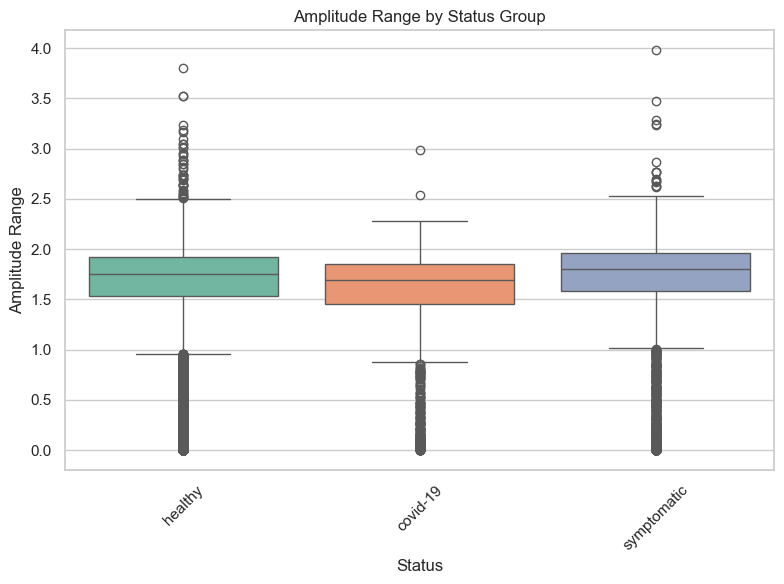

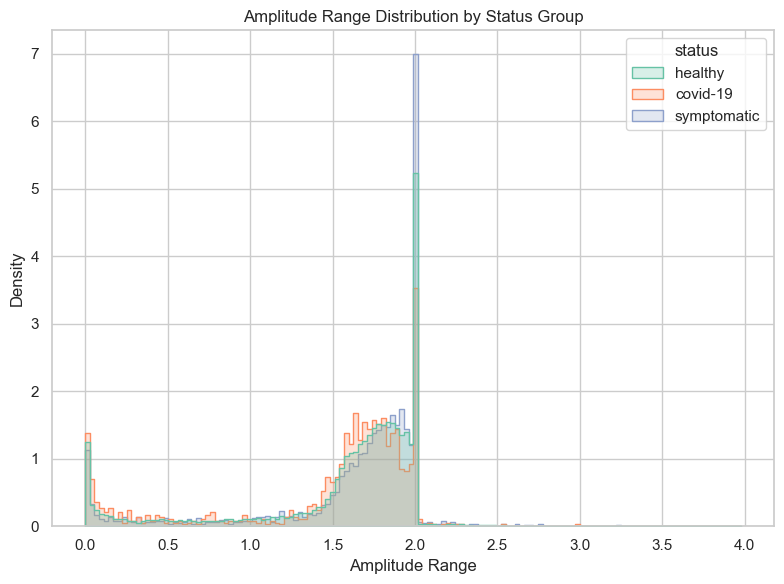

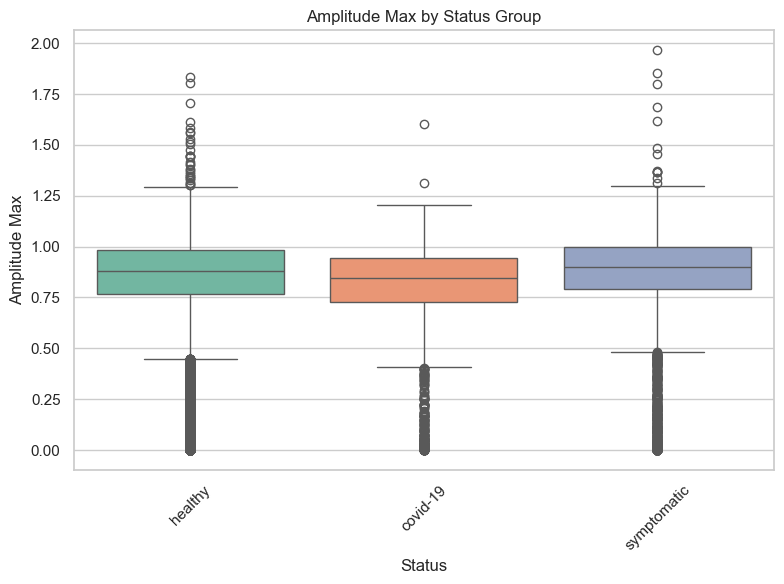

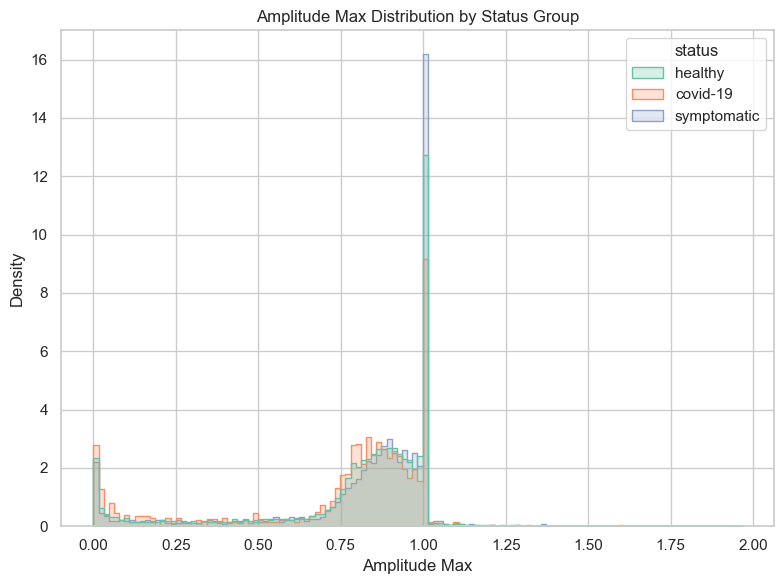

In [95]:
# Convert the list of feature dictionaries into a DataFrame
audio_features_df = pd.DataFrame(audio_features_list)

# Show summary statistics as a visible table
display(audio_features_df.describe())

# Join status labels for grouped plotting without overwriting the main dataframe
audio_features_with_status = audio_features_df.set_index("uuid").join(df_audio["status"])

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=audio_features_with_status,
    x="status",
    y="amplitude_range",
    palette="Set2",
    hue="status",
)
plt.title("Amplitude Range by Status Group")
plt.xlabel("Status")
plt.ylabel("Amplitude Range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# amplitude range distribution
plt.figure(figsize=(8, 6))
sns.histplot(
    data=audio_features_with_status,
    x="amplitude_range",
    hue="status",
    element="step",
    stat="density",
    common_norm=False,
    palette="Set2",
)
plt.title("Amplitude Range Distribution by Status Group")
plt.xlabel("Amplitude Range")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# amplitude max boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=audio_features_with_status,
    x="status",
    y="amplitude_max",
    palette="Set2",
    hue="status",
)
plt.title("Amplitude Max by Status Group")
plt.xlabel("Status")
plt.ylabel("Amplitude Max")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# amplitude max distribution
plt.figure(figsize=(8, 6))
sns.histplot(
    data=audio_features_with_status,
    x="amplitude_max",
    hue="status",
    element="step",
    stat="density",
    common_norm=False,
    palette="Set2",
)
plt.title("Amplitude Max Distribution by Status Group")
plt.xlabel("Amplitude Max")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Selected representative samples per status:


,uuid,status,reason,representative_score,duration_sec,amplitude_range,amplitude_max,audio_path
0,1f6a497a-7d48-4db2-be34-c7760e427427,covid-19,extreme (feature tail),4.742444,13.080000,1.647797,8.523865e-01,COUGHVIDdataset/1f6a497a-7d48-4db2-be34-c7760e...
1,6b234a9d-2305-4452-826d-1a514b3cb6b2,covid-19,extreme (feature tail),6.478777,9.960000,0.000061,3.051758e-05,COUGHVIDdataset/6b234a9d-2305-4452-826d-1a514b...
2,9cf8103f-e52d-4020-a08c-0ebd93e4b557,covid-19,extreme (feature tail),6.478889,9.960000,0.000031,0.000000e+00,COUGHVIDdataset/9cf8103f-e52d-4020-a08c-0ebd93...
3,dd94652b-ff9f-4f9c-b01f-8f5df600e846,covid-19,extreme (feature tail),12.444506,4.307896,2.986030,1.602589e+00,COUGHVIDdataset/dd94652b-ff9f-4f9c-b01f-8f5df6...
4,7288ad05-549c-4cba-b2c2-1c3ee850e750,covid-19,extreme (feature tail),19.005015,0.480000,0.037933,2.093506e-02,COUGHVIDdataset/7288ad05-549c-4cba-b2c2-1c3ee8...
5,4f51059b-0e34-4ae8-8ea8-66630d9b147b,covid-19,typical (near class center),0.025740,9.780000,1.681061,8.454895e-01,COUGHVIDdataset/4f51059b-0e34-4ae8-8ea8-66630d...
6,ccdb32af-58f4-4718-9f6e-eec7e0020382,covid-19,typical (near class center),0.025962,9.780000,1.681213,8.435974e-01,COUGHVIDdataset/ccdb32af-58f4-4718-9f6e-eec7e0...
7,2818c2d1-e833-4f62-ba16-8f564a525398,covid-19,typical (near class center),0.052074,9.780000,1.669922,8.355713e-01,COUGHVIDdataset/2818c2d1-e833-4f62-ba16-8f564a...
8,233a804c-8f2c-42e9-b8e3-c55a26bf9bef,healthy,extreme (feature tail),6.473566,9.798821,0.000000,0.000000e+00,COUGHVIDdataset/233a804c-8f2c-42e9-b8e3-c55a26...
9,23784907-ffd8-42ec-b743-4b74799d0e3c,healthy,extreme (feature tail),6.755272,10.031604,0.000000,2.034587e-34,COUGHVIDdataset/23784907-ffd8-42ec-b743-4b7479...


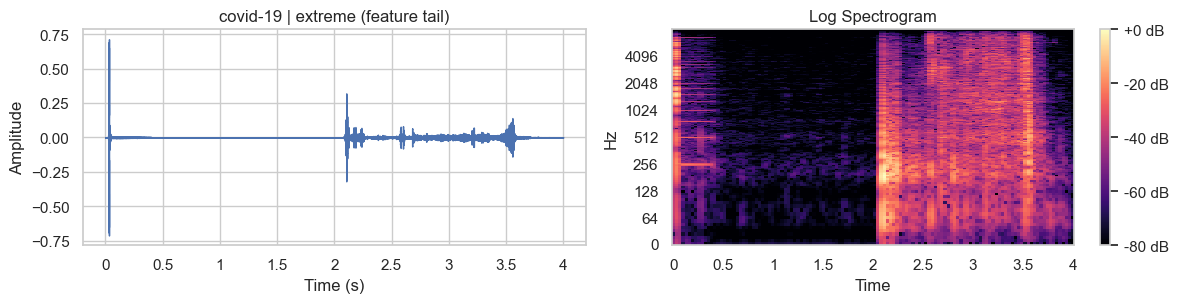

UUID: 1f6a497a-7d48-4db2-be34-c7760e427427 | path: COUGHVIDdataset/1f6a497a-7d48-4db2-be34-c7760e427427.webm


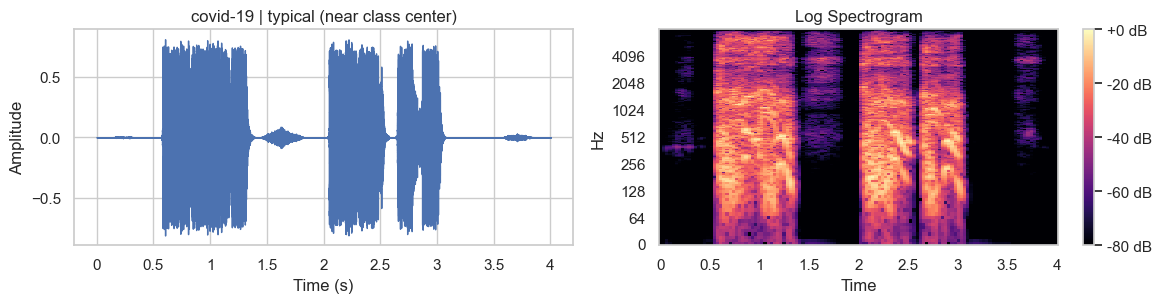

UUID: 4f51059b-0e34-4ae8-8ea8-66630d9b147b | path: COUGHVIDdataset/4f51059b-0e34-4ae8-8ea8-66630d9b147b.webm


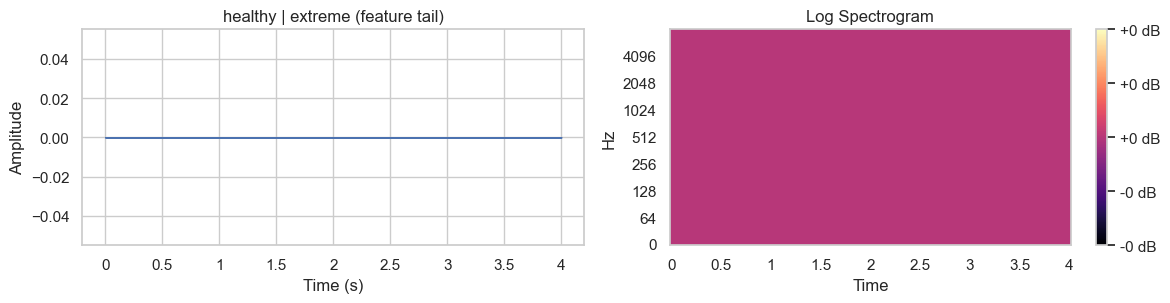

UUID: 233a804c-8f2c-42e9-b8e3-c55a26bf9bef | path: COUGHVIDdataset/233a804c-8f2c-42e9-b8e3-c55a26bf9bef.wav


/Users/georg/Developer/uni/coughvid_analysis/venv/lib/python3.11/site-packages/IPython/lib/display.py:188: RuntimeWarning: invalid value encountered in divide
  scaled = data / normalization_factor * 32767
/Users/georg/Developer/uni/coughvid_analysis/venv/lib/python3.11/site-packages/IPython/lib/display.py:189: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan


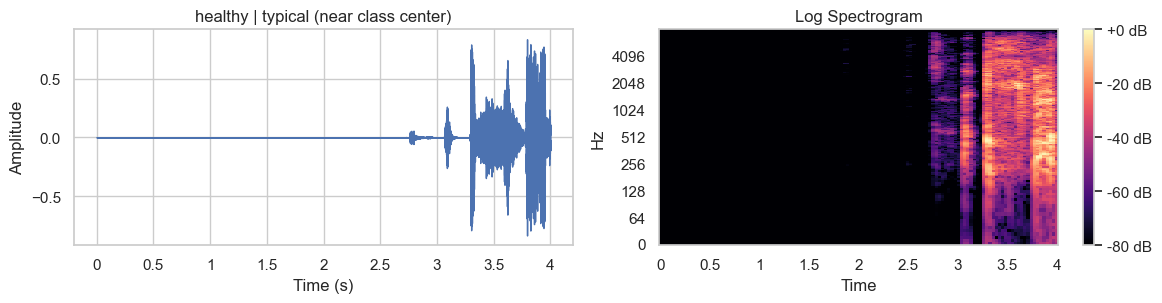

UUID: 1ed2fad7-20c4-4c6b-8c1c-3317dc63b3cc | path: COUGHVIDdataset/1ed2fad7-20c4-4c6b-8c1c-3317dc63b3cc.webm


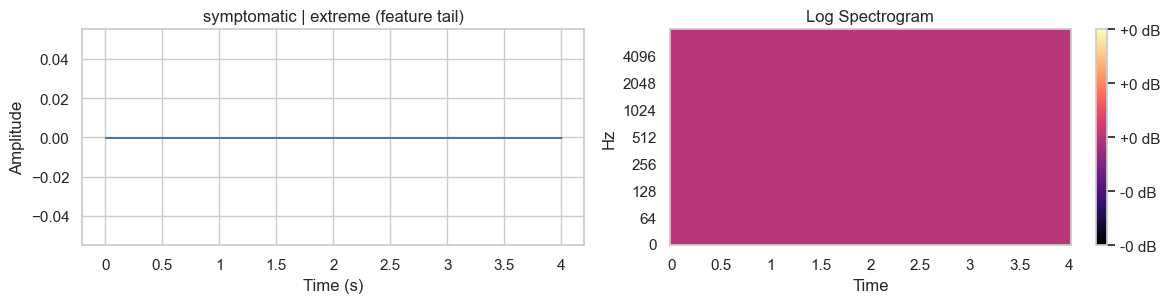

UUID: 257c54fd-45a5-430c-8c8a-63c7d8d5d74a | path: COUGHVIDdataset/257c54fd-45a5-430c-8c8a-63c7d8d5d74a.webm


/Users/georg/Developer/uni/coughvid_analysis/venv/lib/python3.11/site-packages/IPython/lib/display.py:188: RuntimeWarning: invalid value encountered in divide
  scaled = data / normalization_factor * 32767
/Users/georg/Developer/uni/coughvid_analysis/venv/lib/python3.11/site-packages/IPython/lib/display.py:189: RuntimeWarning: invalid value encountered in cast
  return scaled.astype("<h").tobytes(), nchan


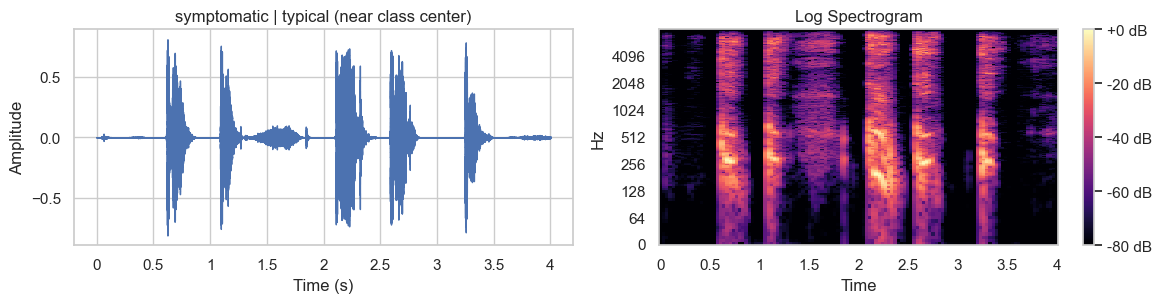

UUID: f0bc6079-5c16-4c95-91be-ddffc7bb37b0 | path: COUGHVIDdataset/f0bc6079-5c16-4c95-91be-ddffc7bb37b0.webm


In [96]:
# ---------------------------------------
# Visualize representative audio samples
# ---------------------------------------
from IPython.display import Audio, display
import librosa.display

# Build a single table with labels + extracted features + audio path.
label_df = df_audio[["status", "audio_path"]].copy()

rep_df = label_df.merge(audio_features_df, on="uuid", how="inner")
rep_df = rep_df.dropna(subset=["status", "audio_path"]).copy()

# Choose informative continuous features for representativeness scoring.
candidate_features = ["duration_sec", "amplitude_range", "amplitude_max", "amplitude_min"]
feature_cols = [c for c in candidate_features if c in rep_df.columns]

if not feature_cols:
    raise ValueError("No numeric feature columns available fxor representative-sample selection.")

def pick_representatives_by_status(df_in, status_col="status", k_typical=3):
    rows = []
    for status, grp in df_in.groupby(status_col, dropna=True):
        g = grp.copy()

        # Robust centrality score: mean absolute deviation from class median, scaled by MAD.
        robust_parts = []
        for col in feature_cols:
            med = g[col].median()
            mad = np.median(np.abs(g[col] - med))
            denom = mad if mad > 1e-12 else 1.0
            robust_parts.append(np.abs((g[col] - med) / denom))

        robust_score = np.vstack([s.to_numpy() for s in robust_parts]).mean(axis=0)
        g["representative_score"] = robust_score

        # Typical samples: closest to class center.
        typical = g.nsmallest(k_typical, "representative_score").copy()
        typical["reason"] = "typical (near class center)"
        rows.append(typical)

        # Extreme samples: tails per feature to show variation.
        extreme_idx = set()
        for col in feature_cols:
            extreme_idx.add(g[col].idxmin())
            extreme_idx.add(g[col].idxmax())
        extremes = g.loc[list(extreme_idx)].copy()
        extremes = extremes[~extremes["uuid"].isin(typical["uuid"])].copy()
        extremes["reason"] = "extreme (feature tail)"
        rows.append(extremes)

    out = pd.concat(rows, ignore_index=True)
    out = out.sort_values([status_col, "reason", "representative_score"], na_position="last")
    out = out.drop_duplicates(subset=["uuid", "reason"]).reset_index(drop=True)
    return out

representative_samples = pick_representatives_by_status(rep_df, k_typical=3)

print("Selected representative samples per status:")
display(
    representative_samples[
        ["uuid", "status", "reason", "representative_score", "duration_sec", "amplitude_range", "amplitude_max", "audio_path"]
    ].head(30)
)

# --- Optional visualization helper ---
def plot_and_play_samples(sample_df, n_per_status=2, sr=16000, max_seconds=4.0):
    chosen = (
        sample_df.groupby(["status", "reason"], group_keys=False)
        .head(n_per_status)
        .reset_index(drop=True)
    )

    for i, row in chosen.iterrows():
        y, sr_native = load_audio(row["audio_path"], sampling_rate=sr, mono=True)
        if max_seconds is not None:
            y = y[: int(max_seconds * sr_native)]

        fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
        librosa.display.waveshow(y, sr=sr_native, ax=axes[0])
        axes[0].set_title(f"{row['status']} | {row['reason']}")
        axes[0].set_xlabel("Time (s)")
        axes[0].set_ylabel("Amplitude")

        S_db = librosa.power_to_db(np.abs(librosa.stft(y)) ** 2, ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr_native, x_axis="time", y_axis="log", ax=axes[1])
        axes[1].set_title("Log Spectrogram")
        fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
        plt.tight_layout()
        plt.show()

        print(f"UUID: {row['uuid']} | path: {row['audio_path']}")
        display(Audio(y, rate=sr_native))

# Run this when you want actual plots + playback
plot_and_play_samples(representative_samples, n_per_status=1, sr=16000, max_seconds=4.0)

### 3 – Preprocessing
Metadata:


Audio:
- Standardization of the audio recording, if necessary
- Amplitude normalization
- Noise / silence removal
- convert stereo to mono

#### 3.1 Preprocess Metadata
- Handling missing values / inconsistent entries
- Encoding categorical variables, if needed
- Features scaling / normalization

In [114]:
preproc_metadata_df = df_audio.join(audio_features_df.set_index("uuid"))

In [115]:
# ------------------------------
# Handling missing data 
# -------------------------------

# Drop columns with more than 90% missing values from the high_missing datafame
cols_to_drop = high_missing.index.tolist()
# display(cols_to_drop)
preproc_metadata_df = preproc_metadata_df.drop(columns=cols_to_drop)

# drop rows with missing status as they are not useful in answering RQ1
preproc_metadata_df = preproc_metadata_df.dropna(subset=['status'])

display(preproc_metadata_df.head())

,Unnamed: 0,datetime,cough_detected,latitude,longitude,age,gender,respiratory_condition,fever_muscle_pain,status,status_SSL,audio_path,has_audio,duration_sec,sampling_rate_hz,amplitude_min,amplitude_max,amplitude_range
uuid,,,,,,,,,,,,,,,,,,
00039425-7f3a-42aa-ac13-834aaa2b6b92,1,2020-04-13 21:30:59.801831+00:00,0.9609,31.3,34.8,15.0,male,false,false,healthy,healthy,COUGHVIDdataset/00039425-7f3a-42aa-ac13-834aaa...,True,9.780,48000,-0.730347,0.746063,1.476410
0007c6f1-5441-40e6-9aaf-a761d8f2da3b,2,2020-10-18 15:38:38.205870+00:00,0.1643,NaN,NaN,46.0,female,false,false,healthy,<NA>,COUGHVIDdataset/0007c6f1-5441-40e6-9aaf-a761d8...,True,9.780,48000,-0.053131,0.050568,0.103699
00098cdb-4da1-4aa7-825a-4f1b9abc214b,3,2021-01-22 22:08:06.742577+00:00,0.1133,47.4,9.4,66.0,female,false,false,healthy,<NA>,COUGHVIDdataset/00098cdb-4da1-4aa7-825a-4f1b9a...,True,10.004,48000,-0.918030,0.989624,1.907654
0009eb28-d8be-4dc1-92bb-907e53bc5c7a,4,2020-04-12 04:02:18.159383+00:00,0.9301,40.0,-75.1,34.0,male,true,false,healthy,healthy,COUGHVIDdataset/0009eb28-d8be-4dc1-92bb-907e53...,True,4.500,48000,-0.880127,0.873962,1.754089
001328dc-ea5d-4847-9ccf-c5aa2a3f2d0f,6,2020-04-13 22:23:06.997578+00:00,0.9968,NaN,NaN,21.0,male,false,false,healthy,healthy,COUGHVIDdataset/001328dc-ea5d-4847-9ccf-c5aa2a...,True,9.840,48000,-0.970764,0.999969,1.970734


In [ ]:
# ------------------------------
# Filter to usable rows
# ------------------------------
preproc_metadata_df = preproc_metadata_df.copy()
print(f"Rows before filtering: {len(preproc_metadata_df):,}")

# Keep rows with a valid audio path if present.
if "audio_path" in preproc_metadata_df.columns:
    preproc_metadata_df = preproc_metadata_df[preproc_metadata_df["audio_path"].astype(str).str.len() > 0].copy()

# Drop rows missing key audio features (when available).
audio_feature_cols = [
    c
    for c in ["duration_sec", "sampling_rate_hz", "amplitude_min", "amplitude_max", "amplitude_range"]
    if c in preproc_metadata_df.columns
 ]
if audio_feature_cols:
    preproc_metadata_df = preproc_metadata_df.dropna(subset=audio_feature_cols)

# Keep only rows with a target label.
target_col = "status"
preproc_metadata_df = preproc_metadata_df.dropna(subset=[target_col])

# filter to only rows with high score of cough detected
preproc_metadata_df = preproc_metadata_df[preproc_metadata_df["cough_detected"] >= 0.5].copy()

print(f"Rows after basic filtering: {len(preproc_metadata_df):,}")

Rows before filtering: 20,664
Rows after basic filtering: 20,664


In [100]:
# # ------------------------------
# # Encoding + scaling pipeline
# # ------------------------------
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, StandardScaler

# # Split features vs target and remove identifier columns.
# id_cols = [c for c in ["uuid", "audio_path"] if c in preprocessed_df.columns]
# X = preprocessed_df.drop(columns=[target_col] + id_cols)
# y = preprocessed_df[target_col]

# # Identify column types.
# numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# categorical_cols = X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()

# numeric_transformer = Pipeline(
#     steps=[
#         ("imputer", SimpleImputer(strategy="median")),
#         ("scaler", StandardScaler()),
#     ]
# )
# categorical_transformer = Pipeline(
#     steps=[
#         ("imputer", SimpleImputer(strategy="most_frequent")),
#         ("onehot", OneHotEncoder(handle_unknown="ignore")),
#     ]
# )

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("num", numeric_transformer, numeric_cols),
#         ("cat", categorical_transformer, categorical_cols),
#     ],
#     remainder="drop",
# )

# print(f"Numeric columns: {len(numeric_cols)}")
# print(f"Categorical columns: {len(categorical_cols)}")

#### 3.2 Preprocess Audio
- Standardisation of the audio recording, if necessary
- Amplitude normalisation
- Noise / silence removal

In [ ]:
# ------------------------------
# Standardize the sample rate
# ------------------------------

# analyze the frequency of sample rates in the dataset to choose a common target sample rate
# sample_rate_counts = preprocessed_df["sampling_rate_hz"].value_counts()
# print("Sample rate distribution:")
# display(sample_rate_counts)

def standardize_sample_rate(audio_path, target_sr=48000):
    # This method will load the audio file and resample it to the target sample rate if necessary
    # Default target sample rate is 48000 Hz, which is the most common sample rate in the dataset based on preliminary analysis
    try:
        y, sr = load_audio(audio_path, sampling_rate=target_sr, mono=True)
        if sr != target_sr:
            raise ValueError(f"Unexpected sample rate after loading: {sr} Hz (expected {target_sr} Hz)")
        return y, sr
    except ValueError as ve:
        print(f"ValueError for {audio_path}: {ve}")
        return None, None
    except Exception as e:
        print(f"Error processing {audio_path}: {type(e).__name__}: {e!r}")
        return None, None


In [118]:
# --------------------------
# Silence and noise removal
# --------------------------

def trim_silence(audio, top_db=30):
    """
    Removes leading and trailing silence.
    top_db: frames quieter than are considered silence.
    Higher top_db = more aggressive trimming.
    """
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=top_db)
    return audio_trimmed


def bandpass_filter(audio, sr, lowcut=100, highcut=8000, order=5):
    """
    Applies a Butterworth bandpass filter to the audio signal.
    lowcut: lower frequency bound in Hz
    highcut: upper frequency bound in Hz
    order: filter order (higher = sharper cutoff)
    """
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist
    
    b, a = butter(order, [low, high], btype="band")
    filtered_audio = filtfilt(b, a, audio)
    return filtered_audio



In [120]:
# ------------------------
# Amplitude Normalization
# ------------------------

def normalise_amplitude(audio):
    # Normalize the audio amplitude to the range [-1, 1] based on the maximum absolute value.
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio

In [ ]:
# ------------------------------------------------
# Full preprocessing pipeline for one audio file
# ------------------------------------------------
from concurrent.futures import ThreadPoolExecutor, as_completed

# Create a new directory for the preprocessed audio files
PREPROCESSED_AUDIO_DIR = "preprocessed_audio"
os.makedirs(PREPROCESSED_AUDIO_DIR, exist_ok=True)

TARGET_SAMPLE_RATE = 48000
MAX_WORKERS = 8
PROGRESS_EVERY = 500

def preprocess_audio_file(audio_path, target_sr, out_path):
    """Load, standardize, trim, filter, normalize, and write a single file."""
    try:
        audio, sr = standardize_sample_rate(audio_path, target_sr)
        if audio is None:
            return False, "load_or_resample_failed"

        audio = trim_silence(audio, top_db=30)
        audio = bandpass_filter(audio, sr, lowcut=100, highcut=8000, order=5)
        audio = normalise_amplitude(audio)

        sf.write(out_path, audio, sr)
        return True, None
    except Exception as e:
        return False, f"{type(e).__name__}: {e!r}"
    

# ------------------------------------------
# Parallel preprocessing of all audio files
# ------------------------------------------

# Build work items once for parallel processing
work_items = []
for uuid, row in df_audio.iterrows():
    audio_path = row.get("audio_path", "")
    if not audio_path:
        continue
    out_path = os.path.join(PREPROCESSED_AUDIO_DIR, f"{uuid}.wav")
    work_items.append((uuid, audio_path, out_path))

print(f"Preprocessing {len(work_items):,} files with {MAX_WORKERS} workers...")

done = 0
failures = 0
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_map = {
        executor.submit(preprocess_audio_file, audio_path, TARGET_SAMPLE_RATE, out_path): (uuid, audio_path)
        for uuid, audio_path, out_path in work_items
    }
    for i, fut in enumerate(as_completed(future_map), start=1):
        ok, err = fut.result()
        if not ok:
            failures += 1
        done += 1
        if i % PROGRESS_EVERY == 0 or i == len(work_items):
            print(f"Processed {i:,}/{len(work_items):,} | failures: {failures}")

print(f"Done. Processed: {done:,} | failures: {failures}")

Preprocessing 34,434 files with 8 workers...
Processed 500/34,434 | failures: 0
Processed 1,000/34,434 | failures: 0
Processed 1,500/34,434 | failures: 0
Processed 2,000/34,434 | failures: 0
Processed 2,500/34,434 | failures: 0
Processed 3,000/34,434 | failures: 0
Processed 3,500/34,434 | failures: 0
Processed 4,000/34,434 | failures: 0
Processed 4,500/34,434 | failures: 0
Processed 5,000/34,434 | failures: 0
Processed 5,500/34,434 | failures: 0
Processed 6,000/34,434 | failures: 0
Processed 6,500/34,434 | failures: 0
Processed 7,000/34,434 | failures: 0
Processed 7,500/34,434 | failures: 0
Processed 8,000/34,434 | failures: 0
Processed 8,500/34,434 | failures: 0
Processed 9,000/34,434 | failures: 0
Processed 9,500/34,434 | failures: 0
Processed 10,000/34,434 | failures: 0
Processed 10,500/34,434 | failures: 0
Processed 11,000/34,434 | failures: 0
Processed 11,500/34,434 | failures: 0
Processed 12,000/34,434 | failures: 0
Processed 12,500/34,434 | failures: 0
Processed 13,000/34,434 | 

Playing original audio for UUID ffdcd501-1205-4644-9f1b-550cc381e74e from COUGHVIDdataset/ffdcd501-1205-4644-9f1b-550cc381e74e.webm


np.float64(0.9985)

Playing preprocessed audio for UUID ffdcd501-1205-4644-9f1b-550cc381e74e from preprocessed_audio/ffdcd501-1205-4644-9f1b-550cc381e74e.wav


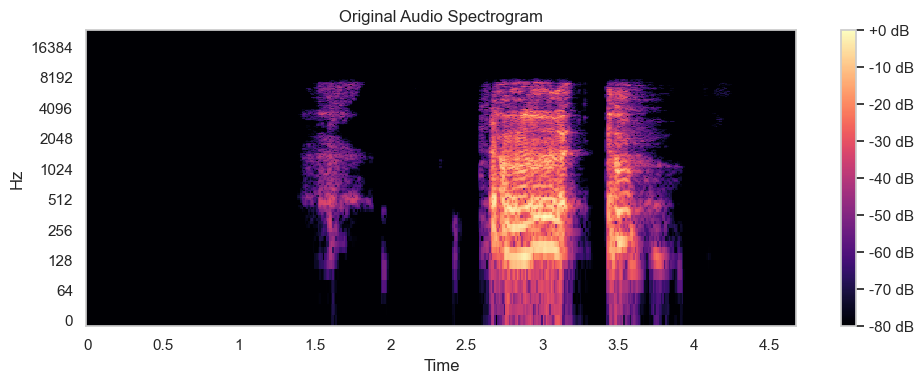

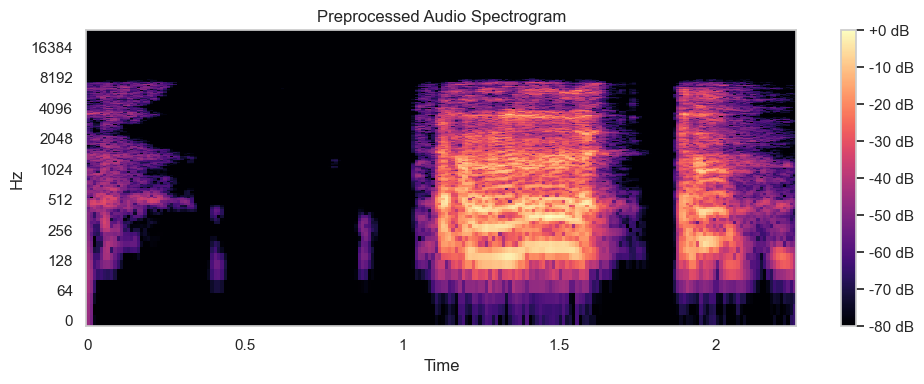

In [ ]:
# find the file with the name 03017811-1838-4593-8d29-5b8804da6512 in the raw data and play it
# 0a84322e-b7a8-4e66-8fa0-7294eb14a2b6
sample_uuid = "ffdcd501-1205-4644-9f1b-550cc381e74e"
file_name = df_audio.loc[sample_uuid, "audio_path"]

# play the original audio
print(f"Playing original audio for UUID {sample_uuid} from {file_name}")
y_orig, sr_orig = load_audio(file_name, sampling_rate=None, mono=True)
display(Audio(y_orig, rate=sr_orig))

display(df_audio.loc[sample_uuid, "cough_detected"])

# play the preprocessed audio
preprocessed_file = os.path.join(PREPROCESSED_AUDIO_DIR, f"{sample_uuid}.wav")
print(f"Playing preprocessed audio for UUID {sample_uuid} from {preprocessed_file}")
y_preproc, sr_preproc = load_audio(preprocessed_file, sampling_rate=None, mono=True)
display(Audio(y_preproc, rate=sr_preproc))


# display waveshow of original and preprocessed audio
def plot_spectrogram(y, sr, title="Spectrogram"):
    S_db = librosa.power_to_db(np.abs(librosa.stft(y)) ** 2, ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spectrogram(y_orig, sr_orig, title="Original Audio Spectrogram")
plot_spectrogram(y_preproc, sr_preproc, title="Preprocessed Audio Spectrogram")


### 4 – Feature Extraction
From the audio signals:
- Time-domain features
- Frequency-domain features
- Time-frequency representations
- Features normalisation
- Dimensionality reduction, if the number of features extracted is large.
- **Explain and justify the chosen transformations and feature engineering
steps**